# **Stakeholder Requirements**
---

## Requirement A: The "Delivery Efficiency" Audit
> **The Problem**: We suspect certain "Rider IDs" are consistently slower than others, affecting our NPS (Net Promoter Score).

>**Task**: Create a new column delivery_duration (Delivered Time - Order Time). Group by Rider_ID and find the top 10 slowest riders who have completed more than 50 orders.

##Requirement B: Peak-Hour Surge Analysis
>The Problem: Need to know when to trigger "Surge Pricing" to attract more riders.

>Task: Extract the Hour from the Order_Time column. Identify which 3-hour window (e.g., 6 PM - 9 PM) has the highest volume of orders.

##Requirement C: The "Distance vs. Delay" Correlation
>The Problem: Marketing wants to know if "Long Distance" is the primary reason for cancellations.

>Task: Calculate the correlation between last_mile_distance and a boolean is_cancelled column.

### **Importing Libraries**

In [1]:
# importing all neccessary modules
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub as kh
#This module provides a portable way of using operating system dependent functionality
import os

In [2]:
# importing latest version of dataset from kaggle
path= kh.dataset_download("cbhavik/swiggyzomato-order-information")
print("path to dataset file:", path)

100%|██████████| 16.9M/16.9M [00:00<00:00, 109MB/s] 

Extracting files...


path to dataset file: /root/.cache/kagglehub/datasets/cbhavik/swiggyzomato-order-information/versions/2


In [3]:
# getting file using os
files=os.listdir(path)
print(files)

['Rider-Info.csv']


In [4]:
# joning path and accessing file using os
df=pd.read_csv(os.path.join(path,"Rider-Info.csv")).copy()
df.head()

,order_time,order_id,order_date,allot_time,accept_time,pickup_time,delivered_time,rider_id,first_mile_distance,last_mile_distance,alloted_orders,delivered_orders,cancelled,undelivered_orders,lifetime_order_count,reassignment_method,reassignment_reason,reassigned_order,session_time,cancelled_time
0,2021-01-26 02:21:35,556753,2021-01-26 00:00:00,2021-01-26 02:21:59,2021-01-26 02:22:08,2021-01-26 02:32:51,2021-01-26 02:49:47,11696,1.5666,2.65,46.0,46.0,0,0.0,621.0,NaN,NaN,NaN,NaN,NaN
1,2021-01-26 02:33:16,556754,2021-01-26 00:00:00,2021-01-26 02:33:57,2021-01-26 02:34:45,2021-01-26 02:50:25,2021-01-26 03:11:15,18117,2.5207,2.76,8.0,8.0,0,0.0,105.0,NaN,NaN,NaN,3.266667,NaN
2,2021-01-26 02:39:49,556755,2021-01-26 00:00:00,2021-01-26 02:39:57,2021-01-26 02:40:13,2021-01-26 02:56:00,2021-01-26 03:12:46,18623,2.2074,4.80,1.0,1.0,0,0.0,66.0,NaN,NaN,NaN,9.816667,NaN
3,2021-01-26 02:47:53,556756,2021-01-26 00:00:00,2021-01-26 02:48:25,2021-01-26 02:49:06,2021-01-26 03:21:51,2021-01-26 03:41:05,15945,2.1894,6.38,1.0,1.0,0,0.0,127.0,NaN,NaN,NaN,17.533333,NaN
4,2021-01-26 03:06:30,556757,2021-01-26 00:00:00,2021-01-26 03:07:21,2021-01-26 03:07:57,2021-01-26 03:31:38,2021-01-26 04:00:15,17589,2.7870,4.01,34.0,34.0,0,0.0,84.0,NaN,NaN,NaN,1.350000,NaN


In [5]:
df.tail()

,order_time,order_id,order_date,allot_time,accept_time,pickup_time,delivered_time,rider_id,first_mile_distance,last_mile_distance,alloted_orders,delivered_orders,cancelled,undelivered_orders,lifetime_order_count,reassignment_method,reassignment_reason,reassigned_order,session_time,cancelled_time
449995,2021-02-06 10:03:16,130226,2021-02-06 00:00:00,2021-02-06 10:03:44,2021-02-06 10:04:14,2021-02-06 10:27:29,2021-02-06 10:44:08,1006,0.5789,0.19,4.0,4.0,0,0.0,127.0,NaN,NaN,NaN,369.516667,NaN
449996,2021-02-06 10:03:17,130227,2021-02-06 00:00:00,2021-02-06 10:03:18,2021-02-06 10:04:34,2021-02-06 10:22:17,2021-02-06 10:31:43,279,1.9863,1.19,81.0,81.0,0,0.0,105.0,NaN,NaN,NaN,239.133333,NaN
449997,2021-02-06 10:03:18,130228,2021-02-06 00:00:00,2021-02-06 10:04:06,2021-02-06 10:04:39,2021-02-06 10:19:06,2021-02-06 10:26:56,3161,1.5944,1.61,28.0,28.0,0,0.0,1488.0,NaN,NaN,NaN,204.150000,NaN
449998,2021-02-06 10:03:19,130229,2021-02-06 00:00:00,2021-02-06 10:03:19,2021-02-06 10:05:41,2021-02-06 10:20:39,2021-02-06 10:30:41,9396,2.8939,4.68,72.0,72.0,0,0.0,105.0,NaN,NaN,NaN,65.583333,NaN
449999,2021-02-06 10:03:24,130230,2021-02-06 00:00:00,2021-02-06 10:03:45,2021-02-06 10:05:14,2021-02-06 10:13:26,2021-02-06 10:19:41,2078,1.8925,0.09,30.0,30.0,0,0.0,108.0,NaN,NaN,NaN,212.000000,NaN


#### **Exploratory Data Analysis-I : MetaData**

In [6]:
# Rows
df.shape[0]

450000

In [7]:
# columns
df.shape[1]

20

In [8]:
# shape
df.shape

(450000, 20)

In [9]:
# columns name (-first_mile_distance : rider to restaurants, -last_mile_distance : Reataurants to customers)
df.columns

Index(['order_time', 'order_id', 'order_date', 'allot_time', 'accept_time',
       'pickup_time', 'delivered_time', 'rider_id', 'first_mile_distance',
       'last_mile_distance', 'alloted_orders', 'delivered_orders', 'cancelled',
       'undelivered_orders', 'lifetime_order_count', 'reassignment_method',
       'reassignment_reason', 'reassigned_order', 'session_time',
       'cancelled_time'],
      dtype='object')

In [10]:
# dataset summary

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450000 entries, 0 to 449999
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_time            450000 non-null  object 
 1   order_id              450000 non-null  int64  
 2   order_date            450000 non-null  object 
 3   allot_time            450000 non-null  object 
 4   accept_time           449843 non-null  object 
 5   pickup_time           447579 non-null  object 
 6   delivered_time        444782 non-null  object 
 7   rider_id              450000 non-null  int64  
 8   first_mile_distance   450000 non-null  float64
 9   last_mile_distance    450000 non-null  float64
 10  alloted_orders        433052 non-null  float64
 11  delivered_orders      432659 non-null  float64
 12  cancelled             450000 non-null  int64  
 13  undelivered_orders    432659 non-null  float64
 14  lifetime_order_count  449947 non-null  float64
 15  

In [11]:
# statstical summary
df.describe(include='all')

,order_time,order_id,order_date,allot_time,accept_time,pickup_time,delivered_time,rider_id,first_mile_distance,last_mile_distance,alloted_orders,delivered_orders,cancelled,undelivered_orders,lifetime_order_count,reassignment_method,reassignment_reason,reassigned_order,session_time,cancelled_time
count,450000,450000.000000,450000,450000,449843,447579,444782,450000.000000,450000.000000,450000.000000,433052.000000,432659.000000,450000.000000,432659.000000,449947.000000,13744,13753,13753.0,446325.000000,5218
unique,252868,NaN,12,246871,254201,257117,257067,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3,NaN,NaN,5176
top,2021-01-30 14:38:36,NaN,2021-02-05 00:00:00,2021-01-29 14:18:11,2021-01-27 16:03:12,2021-01-28 15:29:58,2021-01-30 14:38:14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,auto,Auto Reassignment basis Inaction. coreengine.t...,NaN,NaN,2021-02-03 17:52:03
freq,11,NaN,42341,13,15,11,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13383,7212,NaN,NaN,2
mean,NaN,369143.080767,NaN,NaN,NaN,NaN,NaN,7763.244016,1.229889,2.968873,104.620909,103.950448,0.011596,0.764165,853.640664,NaN,NaN,1.0,220.474779,NaN
std,NaN,131146.906408,NaN,NaN,NaN,NaN,NaN,5592.880135,0.846183,1.884124,90.135492,89.639646,0.107057,1.066473,1502.976162,NaN,NaN,0.0,176.713853,NaN
min,NaN,118350.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000134,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,NaN,NaN,1.0,0.000000,NaN
25%,NaN,257342.750000,NaN,NaN,NaN,NaN,NaN,2805.000000,0.539575,1.470000,36.000000,36.000000,0.000000,0.000000,165.000000,NaN,NaN,1.0,84.100000,NaN
50%,NaN,369842.500000,NaN,NaN,NaN,NaN,NaN,6754.000000,1.138700,2.670000,81.000000,81.000000,0.000000,0.000000,396.000000,NaN,NaN,1.0,175.550000,NaN
75%,NaN,482342.250000,NaN,NaN,NaN,NaN,NaN,11965.000000,1.853000,4.220000,147.000000,146.000000,0.000000,1.000000,948.000000,NaN,NaN,1.0,316.766667,NaN


In [12]:
# Toal drivers (19537 riders)
df["rider_id"].value_counts()

,count
rider_id,
237,228
190,213
11998,209
170,203
853,200
...,...
13174,1
13172,1
7864,1


In [13]:
df[df["accept_time"].isnull()]

,order_time,order_id,order_date,allot_time,accept_time,pickup_time,delivered_time,rider_id,first_mile_distance,last_mile_distance,alloted_orders,delivered_orders,cancelled,undelivered_orders,lifetime_order_count,reassignment_method,reassignment_reason,reassigned_order,session_time,cancelled_time
1700,2021-01-26 06:35:16,558453,2021-01-26 00:00:00,2021-01-26 06:35:18,NaN,NaN,NaN,15903,1.8026,8.55,50.0,50.0,1,0.0,1216.0,NaN,NaN,NaN,51.300000,2021-01-26 06:40:17
4066,2021-01-26 07:20:44,560819,2021-01-26 00:00:00,2021-01-26 07:20:45,NaN,NaN,NaN,3430,1.6112,4.29,29.0,29.0,1,0.0,190.0,NaN,NaN,NaN,52.700000,2021-01-26 07:21:20
9296,2021-01-26 08:58:12,566050,2021-01-26 00:00:00,2021-01-26 08:58:41,NaN,NaN,NaN,20621,2.8689,4.07,NaN,NaN,1,NaN,917.0,NaN,NaN,NaN,120.733333,2021-01-26 09:00:35
13365,2021-01-26 12:42:36,570118,2021-01-26 00:00:00,2021-01-26 12:42:37,NaN,NaN,NaN,10605,0.7966,3.14,11.0,11.0,1,0.0,1546.0,NaN,NaN,NaN,478.333333,2021-01-26 12:47:37
13429,2021-01-26 12:45:42,570182,2021-01-26 00:00:00,2021-01-26 12:45:43,NaN,NaN,NaN,3585,0.9797,7.79,67.0,65.0,1,2.0,144.0,NaN,NaN,NaN,325.666667,2021-01-26 12:47:38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
436851,2021-02-05 17:43:12,197797,2021-02-05 00:00:00,2021-02-05 17:43:47,NaN,NaN,NaN,14594,0.4003,3.10,57.0,57.0,1,0.0,253.0,NaN,NaN,NaN,243.100000,2021-02-05 17:46:34
437757,2021-02-05 17:55:35,198704,2021-02-05 00:00:00,2021-02-05 17:56:36,NaN,NaN,NaN,9156,0.5703,3.28,134.0,133.0,1,1.0,259.0,NaN,NaN,NaN,470.516667,2021-02-05 18:02:28
444007,2021-02-06 07:58:56,124238,2021-02-06 00:00:00,2021-02-06 08:03:56,NaN,NaN,NaN,5535,2.4785,7.35,54.0,54.0,1,0.0,74.0,NaN,NaN,NaN,NaN,2021-02-06 08:03:57
445822,2021-02-06 08:30:17,126053,2021-02-06 00:00:00,2021-02-06 08:30:18,NaN,NaN,NaN,178,2.0771,1.86,40.0,40.0,1,0.0,69.0,NaN,NaN,NaN,172.566667,2021-02-06 08:38:21


In [14]:
# converting order_time, order_date , allot_time, pickup_time, delivered_time, cancelled_time
df['order_time'] = pd.to_datetime(df['order_time'])
df['order_date'] = pd.to_datetime(df['order_date'])
df['allot_time'] = pd.to_datetime(df['allot_time'])
df['pickup_time'] = pd.to_datetime(df['pickup_time'])
df['delivered_time'] = pd.to_datetime(df['delivered_time'])
df['cancelled_time'] = pd.to_datetime(df['cancelled_time'])

In [15]:
# getting desired columns
new_df=pd.concat([df.iloc[:,:15], df.iloc[:,-2:]], axis=1)

In [16]:
new_df.head()

,order_time,order_id,order_date,allot_time,accept_time,pickup_time,delivered_time,rider_id,first_mile_distance,last_mile_distance,alloted_orders,delivered_orders,cancelled,undelivered_orders,lifetime_order_count,session_time,cancelled_time
0,2021-01-26 02:21:35,556753,2021-01-26,2021-01-26 02:21:59,2021-01-26 02:22:08,2021-01-26 02:32:51,2021-01-26 02:49:47,11696,1.5666,2.65,46.0,46.0,0,0.0,621.0,NaN,NaT
1,2021-01-26 02:33:16,556754,2021-01-26,2021-01-26 02:33:57,2021-01-26 02:34:45,2021-01-26 02:50:25,2021-01-26 03:11:15,18117,2.5207,2.76,8.0,8.0,0,0.0,105.0,3.266667,NaT
2,2021-01-26 02:39:49,556755,2021-01-26,2021-01-26 02:39:57,2021-01-26 02:40:13,2021-01-26 02:56:00,2021-01-26 03:12:46,18623,2.2074,4.80,1.0,1.0,0,0.0,66.0,9.816667,NaT
3,2021-01-26 02:47:53,556756,2021-01-26,2021-01-26 02:48:25,2021-01-26 02:49:06,2021-01-26 03:21:51,2021-01-26 03:41:05,15945,2.1894,6.38,1.0,1.0,0,0.0,127.0,17.533333,NaT
4,2021-01-26 03:06:30,556757,2021-01-26,2021-01-26 03:07:21,2021-01-26 03:07:57,2021-01-26 03:31:38,2021-01-26 04:00:15,17589,2.7870,4.01,34.0,34.0,0,0.0,84.0,1.350000,NaT


In [17]:
new_df.shape

(450000, 17)

In [18]:
#new dataset into
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450000 entries, 0 to 449999
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   order_time            450000 non-null  datetime64[ns]
 1   order_id              450000 non-null  int64         
 2   order_date            450000 non-null  datetime64[ns]
 3   allot_time            450000 non-null  datetime64[ns]
 4   accept_time           449843 non-null  object        
 5   pickup_time           447579 non-null  datetime64[ns]
 6   delivered_time        444782 non-null  datetime64[ns]
 7   rider_id              450000 non-null  int64         
 8   first_mile_distance   450000 non-null  float64       
 9   last_mile_distance    450000 non-null  float64       
 10  alloted_orders        433052 non-null  float64       
 11  delivered_orders      432659 non-null  float64       
 12  cancelled             450000 non-null  int64         
 13 

In [19]:
# getting order day, week, weekdays, month, year
new_df['order_year']= new_df['order_date'].dt.year
new_df['order_month']= new_df['order_date'].dt.month
new_df['order_month_name'] = new_df['order_date'].dt.month_name()
new_df['order_day']= new_df['order_date'].dt.day
new_df['order_week']= new_df['order_date'].dt.isocalendar().week
new_df['order_hour']= new_df['order_time'].dt.hour # we are gettting hours in 24 hrs format
new_df['order_day_name'] = new_df['order_date'].dt.day_name()
# time difference between ordered item to delivered time in hours
# Correcting the order to get a positive duration and converting to hours
new_df['delivery_duration'] = (new_df['delivered_time'] - new_df['order_time']).dt.total_seconds() / 3600
# pickup time took by rider to pick up delivery in hours
# Correcting the order to get a positive duration and converting to hours
new_df['pick_up_duraton_overall'] = (new_df['pickup_time'] - new_df['order_time']).dt.total_seconds() / 3600

In [20]:

# date range
start_date=new_df['order_date'].min()
end_date = new_df['order_date'].max()
print(start_date, end_date)

2021-01-26 00:00:00 2021-02-06 00:00:00


### Univariant Analysis

In [21]:
new_df.head()

,order_time,order_id,order_date,allot_time,accept_time,pickup_time,delivered_time,rider_id,first_mile_distance,last_mile_distance,...,cancelled_time,order_year,order_month,order_month_name,order_day,order_week,order_hour,order_day_name,delivery_duration,pick_up_duraton_overall
0,2021-01-26 02:21:35,556753,2021-01-26,2021-01-26 02:21:59,2021-01-26 02:22:08,2021-01-26 02:32:51,2021-01-26 02:49:47,11696,1.5666,2.65,...,NaT,2021,1,January,26,4,2,Tuesday,0.470000,0.187778
1,2021-01-26 02:33:16,556754,2021-01-26,2021-01-26 02:33:57,2021-01-26 02:34:45,2021-01-26 02:50:25,2021-01-26 03:11:15,18117,2.5207,2.76,...,NaT,2021,1,January,26,4,2,Tuesday,0.633056,0.285833
2,2021-01-26 02:39:49,556755,2021-01-26,2021-01-26 02:39:57,2021-01-26 02:40:13,2021-01-26 02:56:00,2021-01-26 03:12:46,18623,2.2074,4.80,...,NaT,2021,1,January,26,4,2,Tuesday,0.549167,0.269722
3,2021-01-26 02:47:53,556756,2021-01-26,2021-01-26 02:48:25,2021-01-26 02:49:06,2021-01-26 03:21:51,2021-01-26 03:41:05,15945,2.1894,6.38,...,NaT,2021,1,January,26,4,2,Tuesday,0.886667,0.566111
4,2021-01-26 03:06:30,556757,2021-01-26,2021-01-26 03:07:21,2021-01-26 03:07:57,2021-01-26 03:31:38,2021-01-26 04:00:15,17589,2.7870,4.01,...,NaT,2021,1,January,26,4,3,Tuesday,0.895833,0.418889


##### Order v/s State


/tmp/ipykernel_2207/1628118137.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="order_month_name", y="order_id", data=new_df, palette="plasma")


Text(0.5, 1.0, 'No of Orders v/s Month')

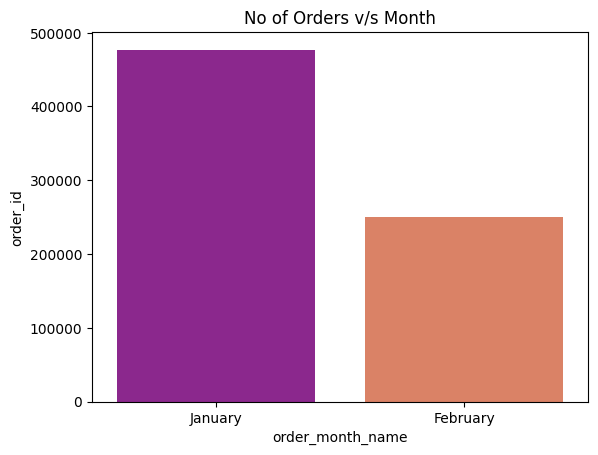

In [22]:
# orders v/s month
sns.barplot(x="order_month_name", y="order_id", data=new_df, palette="plasma")
plt.title("No of Orders v/s Month")

/tmp/ipykernel_2207/3910961807.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="order_day_name", y="order_id", data= new_df, palette="plasma")


Text(0.5, 1.0, 'No of Orders v/s WeekDay')

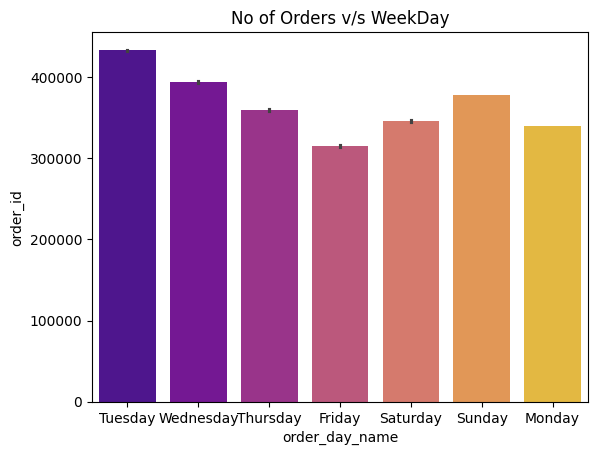

In [23]:
# Orders v/s WeekDay
sns.barplot(x="order_day_name", y="order_id", data= new_df, palette="plasma")
plt.title("No of Orders v/s WeekDay")

/tmp/ipykernel_2207/1883841376.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=new_df['order_hour'], y=new_df['order_id'], palette='plasma')


Text(0.5, 1.0, 'No of Orders v/s Hours')

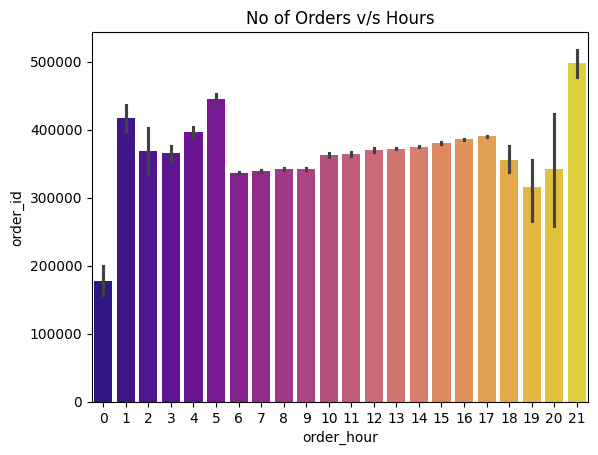

In [24]:
# orders v/s hours
sns.barplot(x=new_df['order_hour'], y=new_df['order_id'], palette='plasma')
plt.title("No of Orders v/s Hours")

In [25]:
# converting different time in different buckets
bin = [0,3,6,9,12,15,18,21,24]
label = ["Late Night", "Early Morning", "Morning", "Noon", "Afternoon", "Eve", "Early_Night", "Night"]
new_df['hours_bucket']= pd.cut(new_df['order_hour'], bins=bin, labels=label, include_lowest=True)

In [26]:
# checking which bucket get which label
new_df[['order_hour', 'hours_bucket']].drop_duplicates().sort_values(by='order_hour')

,order_hour,hours_bucket
356093,0,Late Night
117888,1,Late Night
0,2,Late Night
4,3,Late Night
124,4,Early Morning
424,5,Early Morning
877,6,Early Morning
3010,7,Morning
6214,8,Morning
9386,9,Morning


/tmp/ipykernel_2207/2683709530.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='hours_bucket', y='order_id', data=new_df, palette='plasma')


Text(0.5, 1.0, 'No of Orders v/s Hours Bucket')

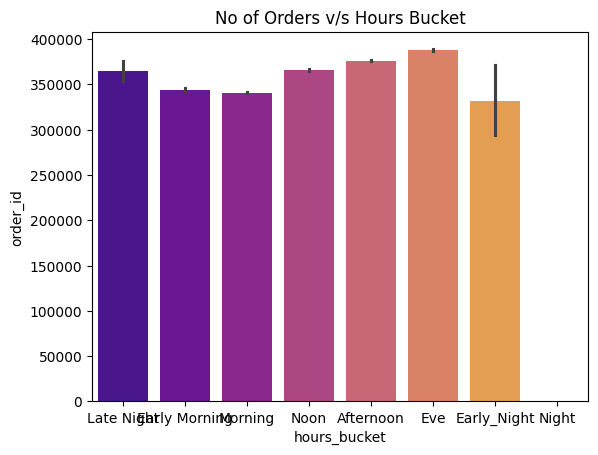

In [37]:
##Requirement B: Peak-Hour Surge Analysis
sns.barplot(x='hours_bucket', y='order_id', data=new_df, palette='plasma')
plt.title('No of Orders v/s Hours Bucket')

In [28]:
# orders v/s last_mile and first_mile distance
df.head()

,order_time,order_id,order_date,allot_time,accept_time,pickup_time,delivered_time,rider_id,first_mile_distance,last_mile_distance,alloted_orders,delivered_orders,cancelled,undelivered_orders,lifetime_order_count,reassignment_method,reassignment_reason,reassigned_order,session_time,cancelled_time
0,2021-01-26 02:21:35,556753,2021-01-26,2021-01-26 02:21:59,2021-01-26 02:22:08,2021-01-26 02:32:51,2021-01-26 02:49:47,11696,1.5666,2.65,46.0,46.0,0,0.0,621.0,NaN,NaN,NaN,NaN,NaT
1,2021-01-26 02:33:16,556754,2021-01-26,2021-01-26 02:33:57,2021-01-26 02:34:45,2021-01-26 02:50:25,2021-01-26 03:11:15,18117,2.5207,2.76,8.0,8.0,0,0.0,105.0,NaN,NaN,NaN,3.266667,NaT
2,2021-01-26 02:39:49,556755,2021-01-26,2021-01-26 02:39:57,2021-01-26 02:40:13,2021-01-26 02:56:00,2021-01-26 03:12:46,18623,2.2074,4.80,1.0,1.0,0,0.0,66.0,NaN,NaN,NaN,9.816667,NaT
3,2021-01-26 02:47:53,556756,2021-01-26,2021-01-26 02:48:25,2021-01-26 02:49:06,2021-01-26 03:21:51,2021-01-26 03:41:05,15945,2.1894,6.38,1.0,1.0,0,0.0,127.0,NaN,NaN,NaN,17.533333,NaT
4,2021-01-26 03:06:30,556757,2021-01-26,2021-01-26 03:07:21,2021-01-26 03:07:57,2021-01-26 03:31:38,2021-01-26 04:00:15,17589,2.7870,4.01,34.0,34.0,0,0.0,84.0,NaN,NaN,NaN,1.350000,NaT


In [ ]:
# orders v/s last_mile and first_mile distance

# Reshape the DataFrame to a long format for plotting both distances
melted_distances_df = new_df.melt(
    id_vars='order_id', # Keep 'order_id' as an identifier
    value_vars=['first_mile_distance', 'last_mile_distance'],
    var_name='distance_type', # New column to indicate if it's first_mile or last_mile
    value_name='distance_value' # New column for the distance value
)

# Now create the line plot.
# 'distance_value' will be on the x-axis, 'order_id' (implicitly its mean) on the y-axis,
# and 'distance_type' will differentiate the lines.
sns.lineplot(x='distance_value', y='order_id', hue='distance_type', data=melted_distances_df, palette='plasma')
plt.title("Order Metric (Mean Order ID) v/s Last Mile and First Mile Distance")
plt.xlabel("Distance (miles)")
plt.ylabel("Order Metric (Mean Order ID)")
plt.show()

In [33]:
# getting a column where cancelled missing is 0 else 1
new_df['cancelled_status']= new_df['cancelled_time'].apply(lambda x: 0 if pd.isna(x) else 1)

In [34]:
new_df

,order_time,order_id,order_date,allot_time,accept_time,pickup_time,delivered_time,rider_id,first_mile_distance,last_mile_distance,...,order_month,order_month_name,order_day,order_week,order_hour,order_day_name,delivery_duration,pick_up_duraton_overall,hours_bucket,cancelled_status
0,2021-01-26 02:21:35,556753,2021-01-26,2021-01-26 02:21:59,2021-01-26 02:22:08,2021-01-26 02:32:51,2021-01-26 02:49:47,11696,1.5666,2.65,...,1,January,26,4,2,Tuesday,0.470000,0.187778,Late Night,0
1,2021-01-26 02:33:16,556754,2021-01-26,2021-01-26 02:33:57,2021-01-26 02:34:45,2021-01-26 02:50:25,2021-01-26 03:11:15,18117,2.5207,2.76,...,1,January,26,4,2,Tuesday,0.633056,0.285833,Late Night,0
2,2021-01-26 02:39:49,556755,2021-01-26,2021-01-26 02:39:57,2021-01-26 02:40:13,2021-01-26 02:56:00,2021-01-26 03:12:46,18623,2.2074,4.80,...,1,January,26,4,2,Tuesday,0.549167,0.269722,Late Night,0
3,2021-01-26 02:47:53,556756,2021-01-26,2021-01-26 02:48:25,2021-01-26 02:49:06,2021-01-26 03:21:51,2021-01-26 03:41:05,15945,2.1894,6.38,...,1,January,26,4,2,Tuesday,0.886667,0.566111,Late Night,0
4,2021-01-26 03:06:30,556757,2021-01-26,2021-01-26 03:07:21,2021-01-26 03:07:57,2021-01-26 03:31:38,2021-01-26 04:00:15,17589,2.7870,4.01,...,1,January,26,4,3,Tuesday,0.895833,0.418889,Late Night,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449995,2021-02-06 10:03:16,130226,2021-02-06,2021-02-06 10:03:44,2021-02-06 10:04:14,2021-02-06 10:27:29,2021-02-06 10:44:08,1006,0.5789,0.19,...,2,February,6,5,10,Saturday,0.681111,0.403611,Noon,0
449996,2021-02-06 10:03:17,130227,2021-02-06,2021-02-06 10:03:18,2021-02-06 10:04:34,2021-02-06 10:22:17,2021-02-06 10:31:43,279,1.9863,1.19,...,2,February,6,5,10,Saturday,0.473889,0.316667,Noon,0
449997,2021-02-06 10:03:18,130228,2021-02-06,2021-02-06 10:04:06,2021-02-06 10:04:39,2021-02-06 10:19:06,2021-02-06 10:26:56,3161,1.5944,1.61,...,2,February,6,5,10,Saturday,0.393889,0.263333,Noon,0
449998,2021-02-06 10:03:19,130229,2021-02-06,2021-02-06 10:03:19,2021-02-06 10:05:41,2021-02-06 10:20:39,2021-02-06 10:30:41,9396,2.8939,4.68,...,2,February,6,5,10,Saturday,0.456111,0.288889,Noon,0


In [36]:
# Requirement A: The "Delivery Efficiency" Audit

# 1. Filter for successfully delivered orders (where 'cancelled' is 0)
delivered_df = new_df[new_df['cancelled_status'] == 0].copy()

# 2. Calculate the count of delivered orders for each rider
rider_order_counts = delivered_df.groupby('rider_id').size().reset_index(name='completed_orders_count')

# 3. Identify riders who have completed more than 50 orders
eligible_riders = rider_order_counts[rider_order_counts['completed_orders_count'] > 50]['rider_id']

# 4. Filter the delivered_df to include only these eligible riders
filtered_riders_df = delivered_df[delivered_df['rider_id'].isin(eligible_riders)]

# 5. Group by Rider_ID and calculate the mean delivery_duration for eligible riders
slowest_riders = filtered_riders_df.groupby('rider_id')['delivery_duration'].mean()

# 6. Sort in descending order to find the top 10 slowest riders
top_10_slowest_riders = slowest_riders.sort_values(ascending=False).head(10)

print("Top 10 slowest riders (who completed more than 50 orders) based on average delivery duration:\n")
print(top_10_slowest_riders)

Top 10 slowest riders (who completed more than 50 orders) based on average delivery duration:

rider_id
14099    1.596671
13988    1.571053
1342     1.363249
5819     1.124388
1545     1.110862
4257     1.086779
10373    1.080864
4395     1.028434
2458     1.008153
15821    1.004334
Name: delivery_duration, dtype: float64


In [46]:
##Requirement C: The "Distance vs. Delay" Correlation
correlation = new_df['last_mile_distance'].corr(new_df['cancelled_status'])
print(f"Correlation between last_mile_distance and cancelled_status: {correlation}") #weakly correlated

Correlation between last_mile_distance and cancelled_status: 0.01869563173862576
